In [1]:
from dateutil.parser import parse 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
plt.rcParams.update({'figure.figsize': (10, 7), 'figure.dpi': 120})

from statsmodels.tsa.seasonal import seasonal_decompose
from dateutil.parser import parse

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from matplotlib import pyplot

from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

from math import sqrt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def mean_absolute_percentage_error(y_true, y_pred): 
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) 

In [2]:
############################################
## Dados diarios sobre mortalidade cardiovascular ##
############################################
df = pd.read_csv('C:/Users/crisr/Documents/ASN_Rocks/Series_Temporais/2. Curso_Completo/Dados/cmort.csv',header=None)
df.head()

,0
0,97.85
1,104.64
2,94.36
3,98.05
4,95.85


In [ ]:
################################
################################
#1. Visualizando a série temporal

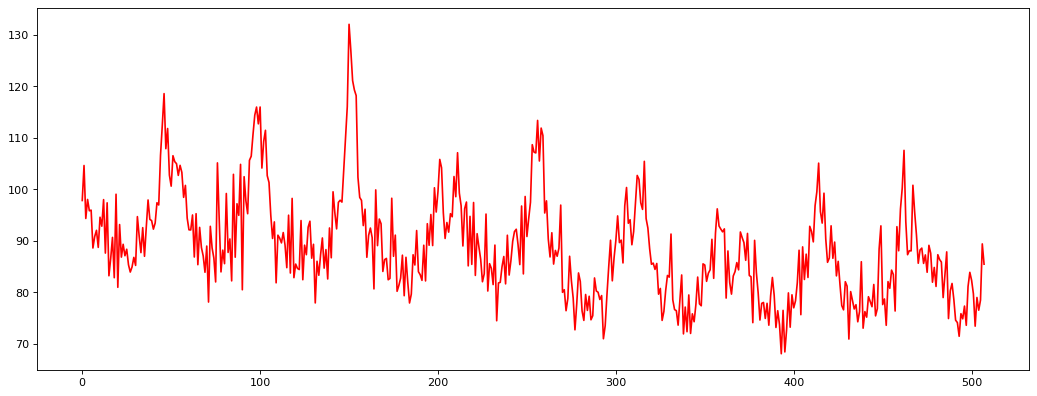

In [3]:
fig  = plt.subplots(1, figsize=(16,6), dpi= 80)
plt.plot(df, color='red')

In [ ]:
################################
################################
#2. Verificando se a série é um Ruído Branco
#Usando Teste Ljung-Box

In [5]:
sm.stats.acorr_ljungbox(df, lags=[5], return_df=True)
#sm.stats.acorr_ljungbox(df, return_df=True)

,lb_stat,lb_pvalue
5,1237.841801,1.866108e-265


p_valor < nível_significancia  => rejeitar a hipotese nula => série não é ruído branco

In [5]:
################################
################################
#3. Verificando se a série é Estacionária
# ADF test 
#ADF test, where the null hypothesis is the time series possesses a unit root and is non-stationary. 
#So, id the P-Value in ADH test is less than the significance level (0.05), you reject the null hypothesis.
result = adfuller(df.values, autolag='AIC')
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
for key, value in result[4].items():
    print('Critial Values:')
    print(f'   {key}, {value}')

ADF Statistic: -4.815687630710126
p-value: 5.074987511904732e-05
Critial Values:
   1%, -3.443339692005083
Critial Values:
   5%, -2.8672689011327894
Critial Values:
   10%, -2.569821287318971


p_valor < nível_significancia  => rejeita a hipotese nula => série é estacionaria

In [ ]:
################################
################################
#4. IDENTIFICAÇÃO
# Verificando autocorrelação e autocorrelação parcial

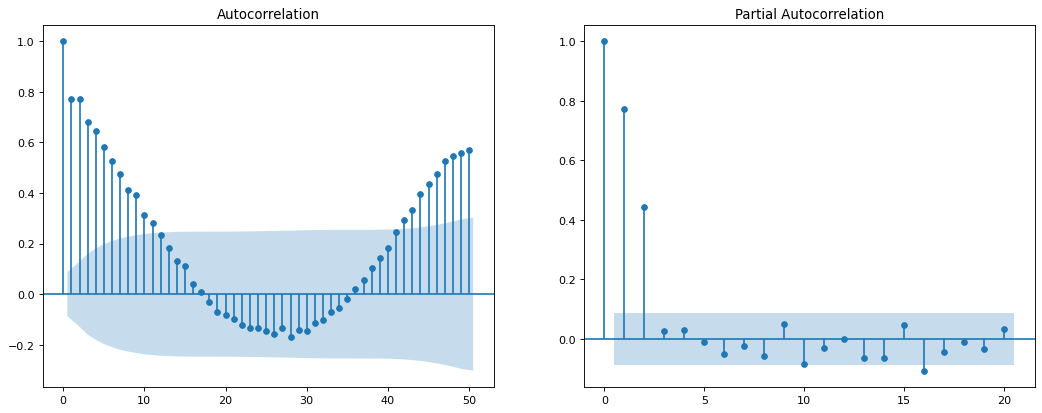

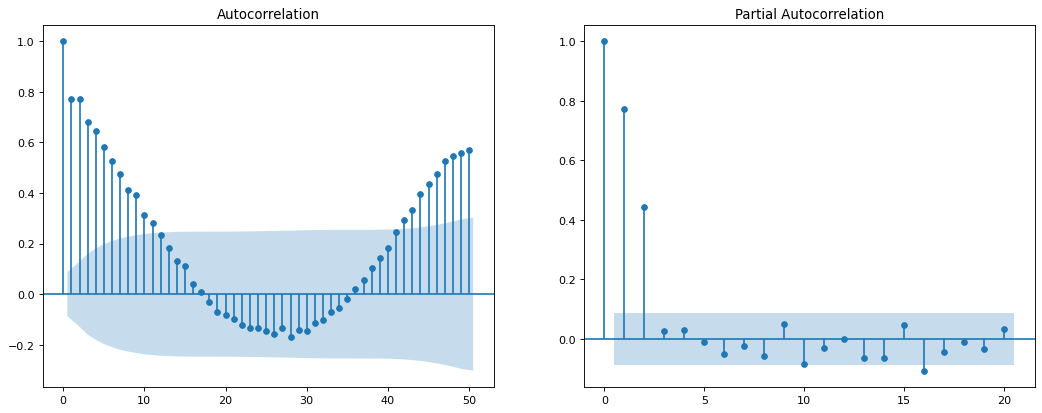

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(16,6), dpi= 80)
plot_acf(df, ax=ax1, lags=50)
plot_pacf(df, ax=ax2, lags=20)

In [ ]:
################################
################################
# 5. ESTIMAÇÃO
# Ajusta o modelo

In [7]:
model = ARIMA(df, order=(2, 0, 0))  #arima(p,d,q)
results_AR = model.fit()  
# summary of fit model
print(results_AR.summary())

                               SARIMAX Results                                
Dep. Variable:                      0   No. Observations:                  508
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -1604.714
Date:                Mon, 30 Oct 2023   AIC                           3217.428
Time:                        21:49:56   BIC                           3234.350
Sample:                             0   HQIC                          3224.064
                                - 508                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         88.8862      2.015     44.101      0.000      84.936      92.836
ar.L1          0.4300      0.037     11.526      0.000       0.357       0.503
ar.L2          0.4425      0.040     10.954      0.0

In [8]:
y_true = df.values
y_pred = results_AR.fittedvalues
r2   = r2_score(y_true, y_pred)
mse  = mean_squared_error(y_true, y_pred)
rmse = sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)

print('R2:   %.3f' % r2)
print('MSE:  %.3f' % mse)
print('RMSE: %.3f' % rmse)
print('MAE:  %.3f' % mae)
print('MAPE: %.3f' % mape)

R2:   0.674
MSE:  32.508
RMSE: 5.702
MAE:  4.504
MAPE: 0.113


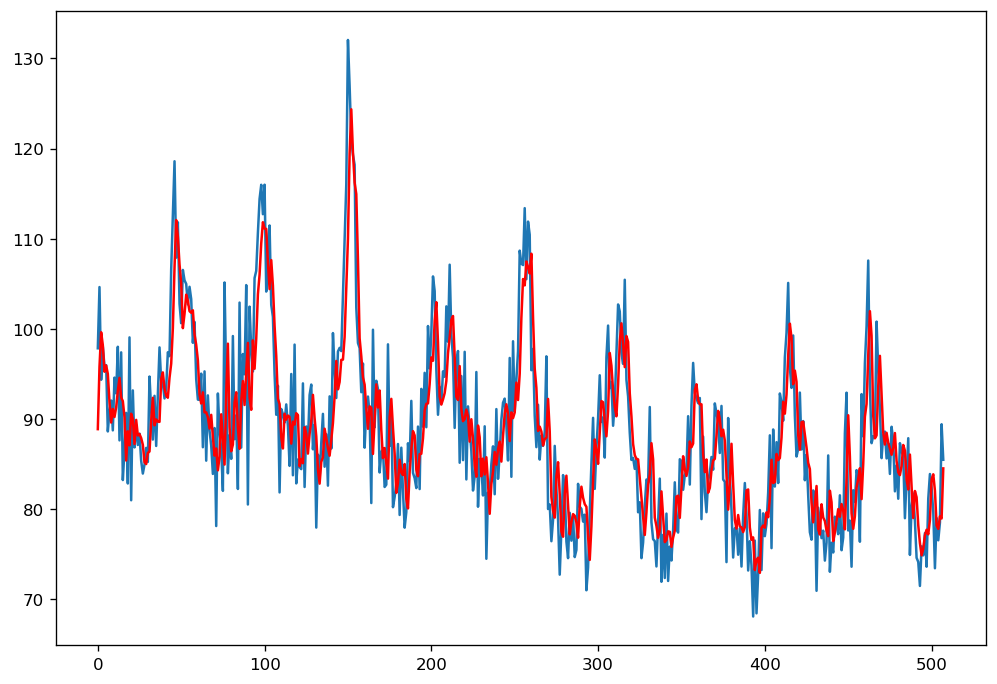

In [9]:
plt.plot(df)
plt.plot(results_AR.fittedvalues, color='red')

In [ ]:
################################
################################
# 6. VERIFICAÇÃO
# Avalia a qualidade do ajuste 

In [10]:
# Aplicando teste do ruido branco do resíduo
sm.stats.acorr_ljungbox(results_AR.resid, lags=[10], return_df=True)

,lb_stat,lb_pvalue
10,7.798056,0.648555


In [ ]:
# p_valor > nível_significancia  => aceita a hipotese nula => série é ruído branco

In [ ]:
# # Analisa também o residuo para verificar se satisfaz as condições de ruido branco
# # line plot of residuals
# residuals = results_AR.resid
# residuals.plot()
# pyplot.show()
# # density plot of residuals
# residuals.plot(kind='kde')
# pyplot.show()
# # summary stats of residuals
# print(residuals.describe())

In [11]:
################################
################################
# 6. PREVISÃO
predictions = results_AR.forecast(30)

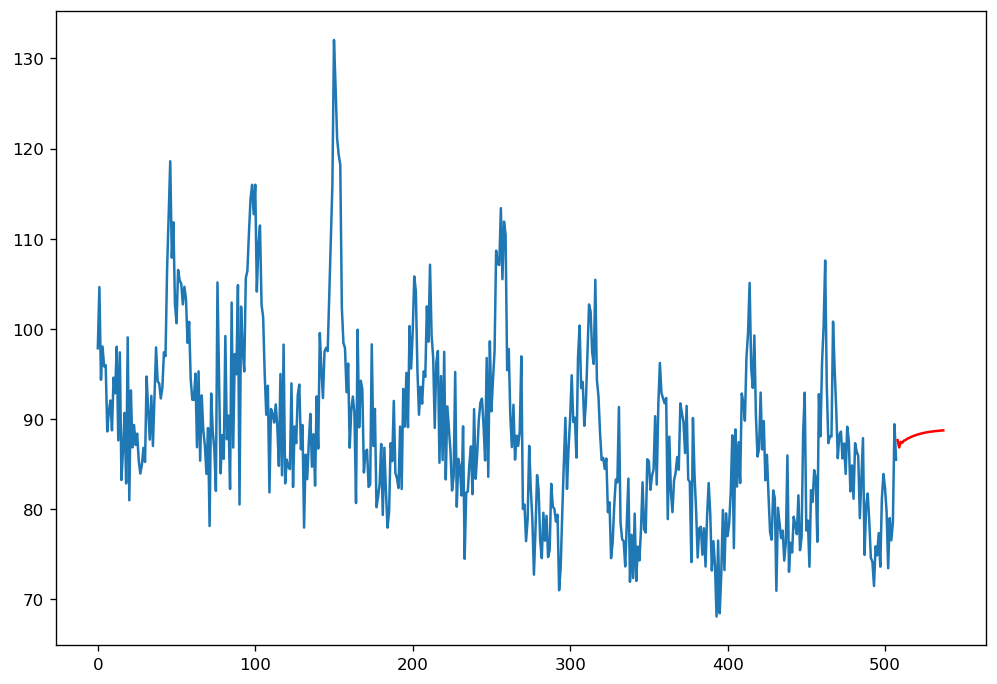

In [12]:
# plot forecasts against actual outcomes
pyplot.plot(df)
pyplot.plot(predictions, color='red')
pyplot.show()